In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir("../data")

sales_pd = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
sales_pd.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#info about columns of dataframe
sales_pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
#null values
sales_pd.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
#no duplicated
print(sales_pd.duplicated().sum())
print("__________________________________________________________________________________________________")


0
__________________________________________________________________________________________________


ANALYSIS
__________________________________________________________________________________________________
The category most sell
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64
__________________________________________________________________________________________________
The subcategory of technology most sell
<StringArray>
['Phones', 'Accessories', 'Machines', 'Copiers']
Length: 4, dtype: str
Sub-Category
Accessories    167380.318
Copiers        149528.030
Machines       189238.631
Phones         330007.054
Name: Sales, dtype: float64


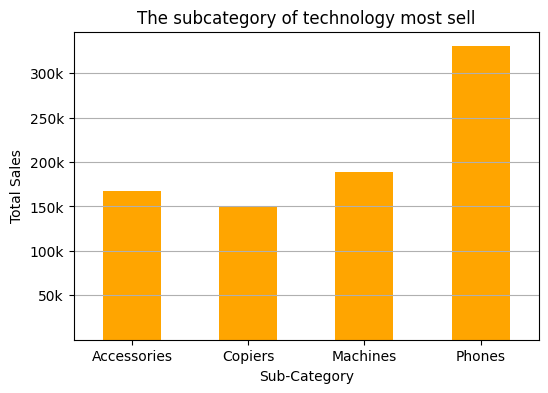

__________________________________________________________________________________________________


In [7]:
print("ANALYSIS")
print("__________________________________________________________________________________________________")

print("The category most sell")
#The cat most sell
print(sales_pd["Category"].unique())
sales_category = sales_pd.groupby("Category")["Sales"].sum()
print(sales_category)

print("__________________________________________________________________________________________________")
print("The subcategory of technology most sell")
#the tech most sell
tech_cat = sales_pd[sales_pd["Category"] == "Technology"]
print(tech_cat["Sub-Category"].unique())
tech_sub = tech_cat.groupby("Sub-Category")["Sales"].sum()
print(tech_sub)
plt.figure(figsize=(6,4))
tech_sub.plot(kind="bar", color="orange")
plt.title("The subcategory of technology most sell")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=360)
plt.yticks([50000, 100000, 150000, 200000, 250000, 300000],['50k', '100k', '150k', '200k', '250k', '300k'])
plt.grid(axis="y")
plt.show()
print("__________________________________________________________________________________________________")

Profitability by Category
Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


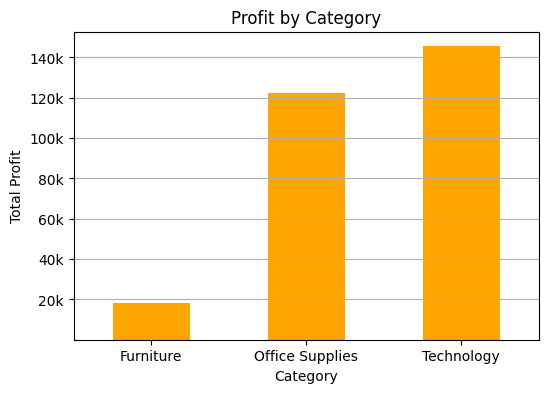

The category Technology: 145454.9481
__________________________________________________________________________________________________


In [8]:
print("Profitability by Category")
profit_category = sales_pd.groupby("Category")["Profit"].sum()
print(profit_category)
plt.figure(figsize=(6,4))
profit_category.plot(kind="bar", color="orange")
plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=360)
plt.yticks([20000, 40000, 60000, 80000, 100000, 120000, 140000],['20k', '40k', '60k', '80k', '100k', '120k', '140k'])
plt.grid(axis="y")
plt.show()
print("The category " + profit_category.idxmax() + ": " + str(profit_category.sort_values(ascending=False).values[0]))

print("__________________________________________________________________________________________________")


Customer Segment Analysis
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


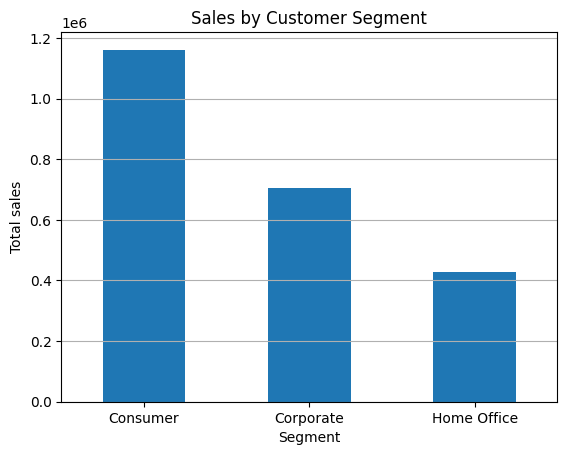

The segment Consumer: 1161401.345
__________________________________________________________________________________________________


In [9]:
print("Customer Segment Analysis")
sales_segment = sales_pd.groupby("Segment")["Sales"].sum()
print(sales_segment)
sales_segment.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.ylabel("Total sales")
plt.xticks(rotation=360)
plt.grid(axis="y")
plt.show()
print("The segment " + sales_segment.idxmax() + ": " + str(sales_segment.sort_values(ascending=False).values[0]))
print("__________________________________________________________________________________________________")

In [10]:
print("Top cities with the most sales")
top_cities = sales_pd.groupby("City")["Sales"].sum().sort_values(ascending=False).head(5)
print(top_cities)
print("__________________________________________________________________________________________________")

Top cities with the most sales
City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
Name: Sales, dtype: float64
__________________________________________________________________________________________________


In [11]:
print("Top best selling products")
top_products = sales_pd.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)
print("__________________________________________________________________________________________________")

Top best selling products
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64
___________________________________________

Discount Impact on Profit
Statistical analysis


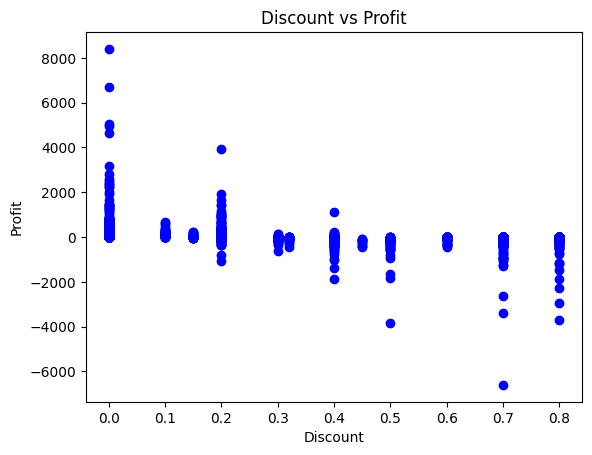

Weak negative relationship: -0.21948745637176834
__________________________________________________________________________________________________


In [15]:
print("Discount Impact on Profit")
print("Statistical analysis")


corr = sales_pd["Discount"].corr(sales_pd["Profit"])

plt.scatter(sales_pd["Discount"], sales_pd["Profit"], color = "blue")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()
if corr > 0.5:
    print("Strong positive relationship: " + str(corr))
elif corr > 0:
    print("Weak positive relationship: " + str(corr))
elif corr < -0.5:
    print("Strong negative relationship: " + str(corr))
elif corr < 0:
    print("Weak negative relationship: " + str(corr))
else:
    print("No correlation")
print("__________________________________________________________________________________________________")

In [14]:
print("Author")
print('Stivens Vega')

Author
Stivens Vega
